<a href="https://colab.research.google.com/github/mohammad64874-boop/ml-student-performance/blob/main/ML_Lab_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 1000

data = {
    'study_hours': np.random.randint(1, 41, rows),
    'attendance': np.random.randint(50, 101, rows),
    'previous_score': np.random.randint(40, 101, rows),
    'sleep_hours': np.random.randint(4, 9, rows)
}

pass_status = []

for i in range(rows):
    if (
        data['study_hours'][i] >= 5 and
        data['attendance'][i] >= 70 and
        data['previous_score'][i] >= 50 and
        data['sleep_hours'][i] >= 5
    ):
        pass_status.append(1)
    else:
        pass_status.append(0)

data['pass'] = pass_status

df = pd.DataFrame(data)

print(df.head())

print("Dataset Shape:", df.shape)

   study_hours  attendance  previous_score  sleep_hours  pass
0           39          63              83            7     0
1           29          89              77            8     1
2           15          90              59            4     0
3            8          71              62            4     0
4           21          60              84            7     0
Dataset Shape: (1000, 5)


In [6]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(1000, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   study_hours     1000 non-null   int64
 1   attendance      1000 non-null   int64
 2   previous_score  1000 non-null   int64
 3   sleep_hours     1000 non-null   int64
 4   pass            1000 non-null   int64
dtypes: int64(5)
memory usage: 39.2 KB
None
       study_hours   attendance  previous_score  sleep_hours         pass
count  1000.000000  1000.000000     1000.000000  1000.000000  1000.000000
mean     20.991000    75.557000       69.219000     6.035000     0.367000
std      11.780055    14.581405       17.453357     1.424712     0.482228
min       1.000000    50.000000       40.000000     4.000000     0.000000
25%      11.000000    63.000000       54.000000     5.000000     0.000000
50%      22.000000    76.000000       69.000000     6.000000     0.000000
75%      31.250000    

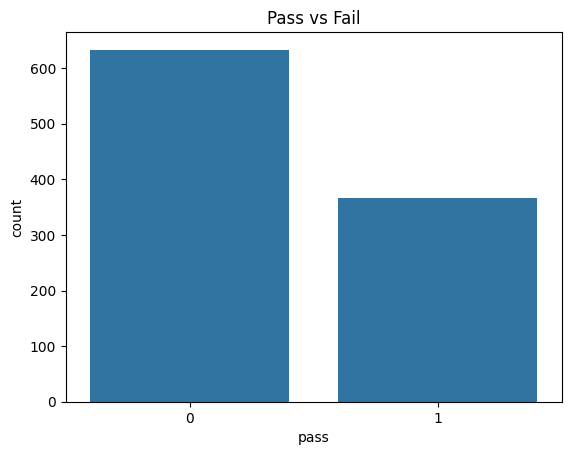

In [7]:
sns.countplot(x='pass', data=df)
plt.title("Pass vs Fail")
plt.show()

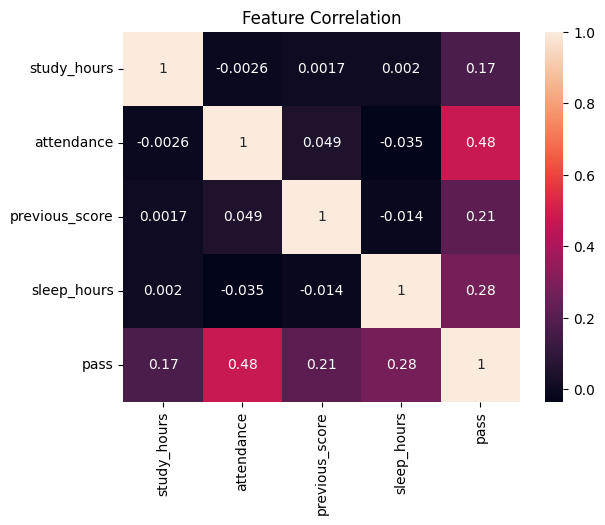

In [8]:
sns.heatmap(df.corr(), annot=True)
plt.title("Feature Correlation")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('pass', axis=1)
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [11]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Logistic Regression Accuracy: 0.84
Decision Tree Accuracy: 1.0


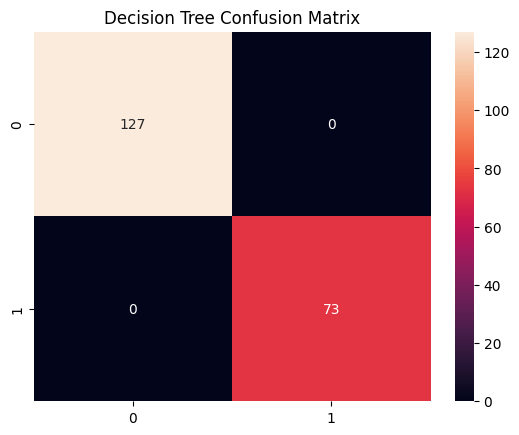

In [13]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d')
plt.title("Decision Tree Confusion Matrix")
plt.show()

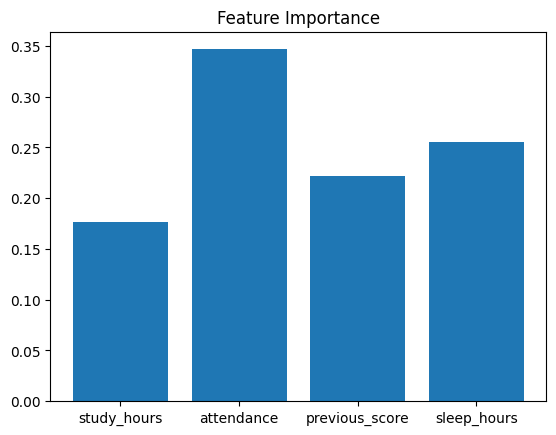

In [14]:
plt.bar(X.columns, dt.feature_importances_)
plt.title("Feature Importance")
plt.show()